# The DFT Matrix and the FFT Factorization

The **Discrete Fourier Transform** of a vector $f \in \mathbb{C}^n$ is the linear map $\hat{f} = F_n f$, where the **DFT matrix** is:
$$
(F_n)_{jk} = \omega_n^{jk}, \qquad \omega_n = e^{2\pi i / n}, \quad j,k = 0,\ldots,n-1.
$$
The $j$-th row of $F_n$ is the $j$-th Fourier atom sampled at $n$ points. The matrix $F_n$ is **unitary** (up to $\sqrt{n}$): $F_n F_n^* = n I$, so the inverse DFT is $f = \tfrac{1}{n} F_n^* \hat{f}$.

## Convolution theorem

A fundamental property of $F_n$ is that it diagonalizes **circular convolution**: if $h = f * g$ (cyclic convolution), then
$$
\hat{h} = \hat{f} \odot \hat{g},
$$
where $\odot$ is elementwise multiplication. Equivalently, the circulant matrix $C_g$ (whose columns are cyclic shifts of $g$) is diagonalized by $F_n$:
$$
C_g = F_n^* \operatorname{diag}(\hat{g})\, F_n.
$$

## Cooley–Tukey FFT factorization

A naive evaluation of $F_n f$ takes $O(n^2)$ operations. The **Fast Fourier Transform** (Cooley–Tukey, 1965) exploits the structure of $F_n$ to reduce this to $O(n \log n)$ by writing:
$$
F_n = E_n \cdot D_n \cdot \begin{pmatrix} F_{n/2} & 0 \\ 0 & F_{n/2} \end{pmatrix} \cdot I_n,
$$
where $E_n$ is a butterfly permutation (even/odd reordering), $D_n = \operatorname{diag}(1, \omega_n, \omega_n^2, \ldots)$ are twiddle factors, and the block diagonal $F_{n/2} \oplus F_{n/2}$ is applied recursively. The factorization has depth $\log_2 n$.

## Environment

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

plt.rcParams['figure.dpi'] = 120

def rainb(Z):
    """Rainbow colorization of a complex matrix (phase = hue, magnitude = value)."""
    angle = np.angle(Z) / (2*np.pi) % 1
    mag   = np.abs(Z) / (np.max(np.abs(Z)) + 1e-10)
    R = np.clip(0.5 + 0.5*np.cos(2*np.pi*(angle)), 0, 1) * mag
    G = np.clip(0.5 + 0.5*np.cos(2*np.pi*(angle - 1/3)), 0, 1) * mag
    B = np.clip(0.5 + 0.5*np.cos(2*np.pi*(angle - 2/3)), 0, 1) * mag
    return np.stack([R, G, B], axis=-1)

## Visualizing the DFT matrix

The DFT matrix is complex-valued. We use a **rainbow colorization**: hue encodes the phase $\arg(F_{jk})$ and brightness encodes the magnitude. Every entry has unit magnitude, so the matrix is a grid of pure phases — the hue sweeps periodically as $(j,k)$ increases.

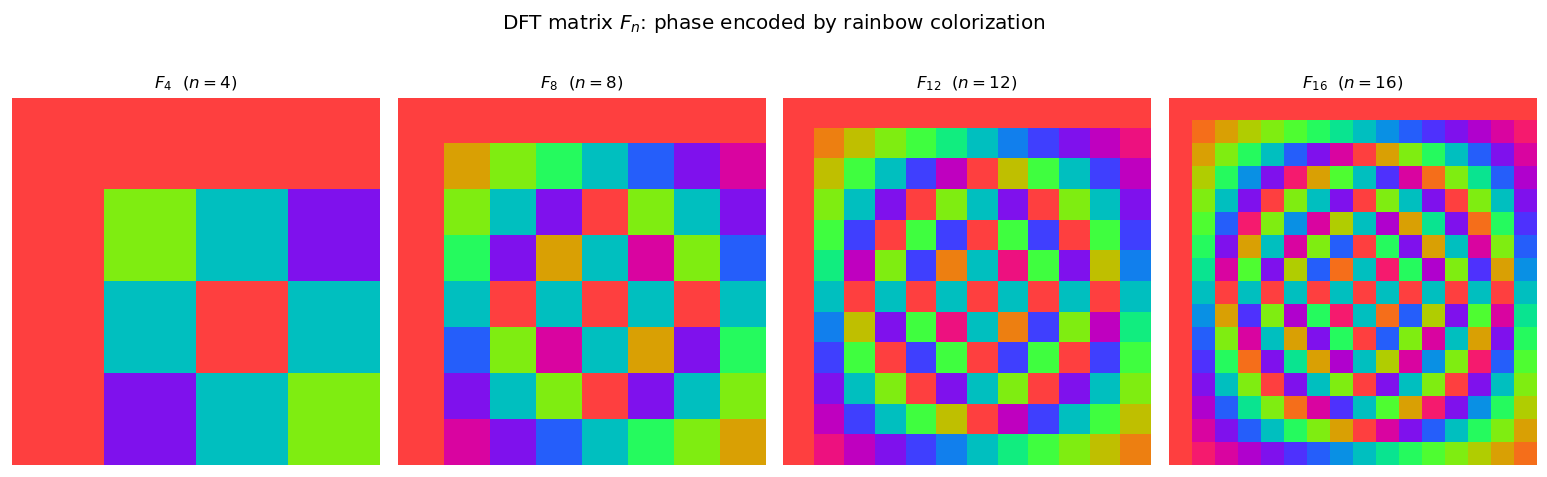

In [2]:
sizes = [4, 8, 12, 16]
fig, axes = plt.subplots(1, len(sizes), figsize=(13, 4))
for ax, n in zip(axes, sizes):
    j = np.arange(n); k = np.arange(n)
    F = np.exp(2j * np.pi / n * np.outer(j, k))
    ax.imshow(rainb(F), interpolation='nearest')
    ax.set_title(f'$F_{{{n}}}$  ($n={n}$)', fontsize=10)
    ax.axis('off')
fig.suptitle('DFT matrix $F_n$: phase encoded by rainbow colorization', y=1.02)
plt.tight_layout()
plt.show()

## Convolution theorem verification

We verify that cyclic convolution in the time domain equals elementwise multiplication in the frequency domain. The circulant matrix $C_g$ is diagonalized by $F_n$.

Max error |C_g f - ifft(fft(f)*fft(g))|: 1.33e-15


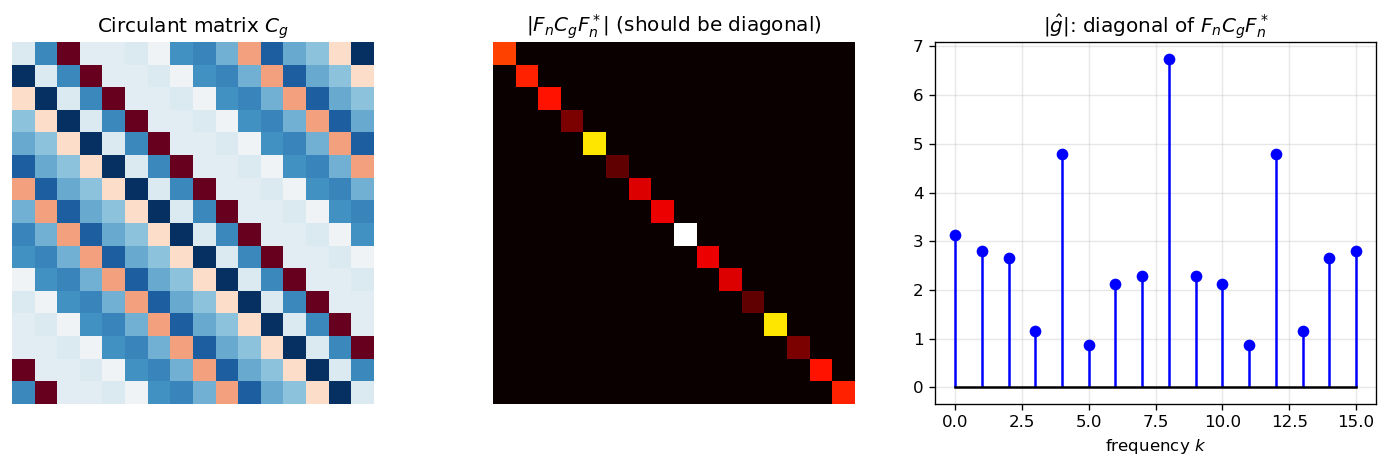

In [3]:
rng = np.random.default_rng(42)
n = 16

f_vec = rng.standard_normal(n)
g_vec = rng.standard_normal(n)

# Build circulant matrix
C_g = np.array([np.roll(g_vec, k) for k in range(n)]).T

# Convolution via matrix multiply vs DFT product
conv_direct = C_g @ f_vec
conv_fft    = np.fft.ifft(np.fft.fft(f_vec) * np.fft.fft(g_vec)).real

print(f'Max error |C_g f - ifft(fft(f)*fft(g))|: {np.max(np.abs(conv_direct - conv_fft)):.2e}')

# Visualize the circulant matrix
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(C_g, cmap='RdBu_r'); axes[0].set_title('Circulant matrix $C_g$'); axes[0].axis('off')

# Diagonalization: F C_g F* = diag(fft(g))
F_n = np.exp(2j * np.pi / n * np.outer(np.arange(n), np.arange(n))) / np.sqrt(n)
D = F_n @ C_g @ F_n.conj().T
axes[1].imshow(np.abs(D), cmap='hot')
axes[1].set_title('$|F_n C_g F_n^*|$ (should be diagonal)'); axes[1].axis('off')

axes[2].stem(np.arange(n), np.abs(np.fft.fft(g_vec)), linefmt='b-', markerfmt='bo', basefmt='k')
axes[2].set_title('$|\\hat{g}|$: diagonal of $F_n C_g F_n^*$')
axes[2].set_xlabel('frequency $k$'); axes[2].grid(alpha=0.3)
plt.tight_layout()
plt.show()

## FFT butterfly factorization

The Cooley–Tukey factorization writes $F_n = P \cdot (F_{n/2} \oplus F_{n/2}) \cdot D \cdot E$ where:
- $E$: even-odd reordering permutation.
- $D$: diagonal twiddle factors $\omega_n^k$.
- $F_{n/2} \oplus F_{n/2}$: two smaller DFTs applied independently.
- $P$: butterfly combination.

We verify the factorization and visualize each factor.

Max factorization error: 9.51e-15


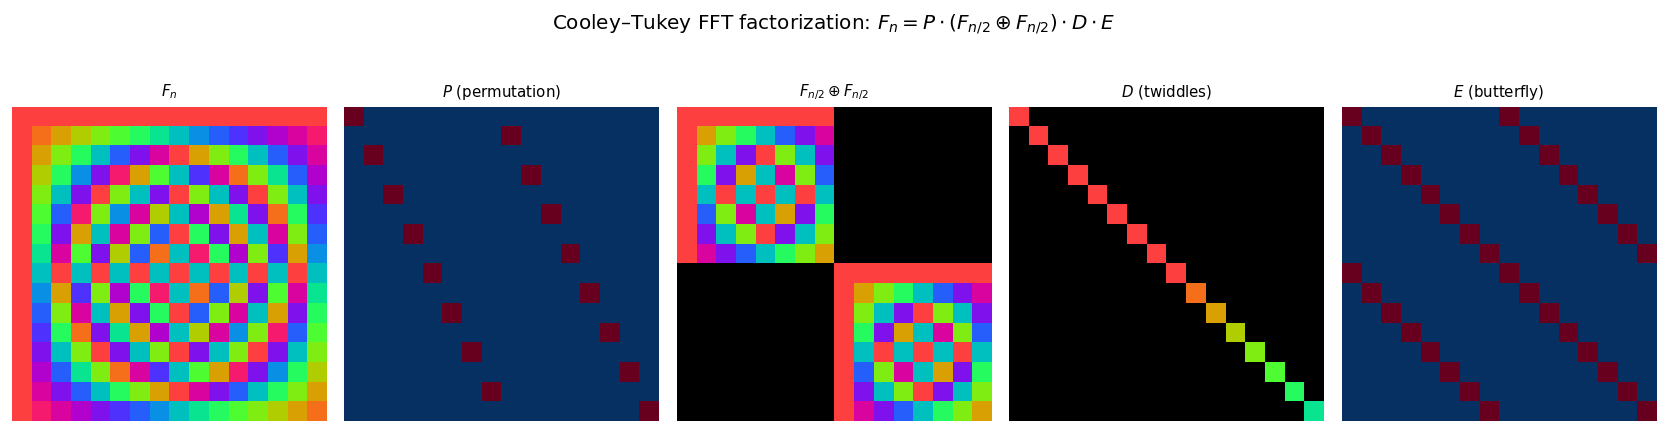

In [4]:
n = 16
omega = np.exp(2j * np.pi / n)
j = np.arange(n); k = np.arange(n)
F_n_full = np.exp(2j * np.pi / n * np.outer(j, k))
F_h = np.exp(2j * np.pi / (n//2) * np.outer(np.arange(n//2), np.arange(n//2)))

# Even-odd interleaving: [0,2,4,...,n-2, 1,3,...,n-1]
idx_eo = np.concatenate([np.arange(0, n, 2), np.arange(1, n, 2)])
I_eo = np.eye(n)[idx_eo]  # permutation matrix

# Double Fourier block
FF = np.zeros((n, n), dtype=complex)
FF[:n//2, :n//2] = F_h
FF[n//2:, n//2:] = F_h

# Diagonal twiddle D
d_vals = np.concatenate([np.ones(n//2), np.array([omega**k for k in range(n//2)])])
D_mat = np.diag(d_vals)

# Butterfly EO combination
E_mat = np.block([[np.eye(n//2), np.eye(n//2)],
                  [np.eye(n//2), -np.eye(n//2)]])

F_reconstructed = I_eo.T @ FF @ D_mat @ E_mat
print(f'Max factorization error: {np.max(np.abs(F_n_full - F_reconstructed)):.2e}')

fig, axes = plt.subplots(1, 5, figsize=(14, 3.5))
for ax, (mat, title) in zip(axes, [
    (F_n_full, '$F_n$'),
    (I_eo.T,   '$P$ (permutation)'),
    (FF,       '$F_{n/2}\\oplus F_{n/2}$'),
    (D_mat,    '$D$ (twiddles)'),
    (E_mat,    '$E$ (butterfly)'),
]):
    ax.imshow(rainb(mat) if np.iscomplexobj(mat) else np.abs(mat),
              cmap='RdBu_r' if not np.iscomplexobj(mat) else None,
              aspect='equal', interpolation='nearest')
    ax.set_title(title, fontsize=9); ax.axis('off')
plt.suptitle('Cooley–Tukey FFT factorization: $F_n = P \\cdot (F_{n/2} \\oplus F_{n/2}) \\cdot D \\cdot E$', y=1.05)
plt.tight_layout()
plt.show()

## Computational complexity: DFT vs FFT

The DFT naively requires $O(n^2)$ multiplications. The FFT's recursive doubling gives $O(n \log_2 n)$. We measure the actual runtime difference.

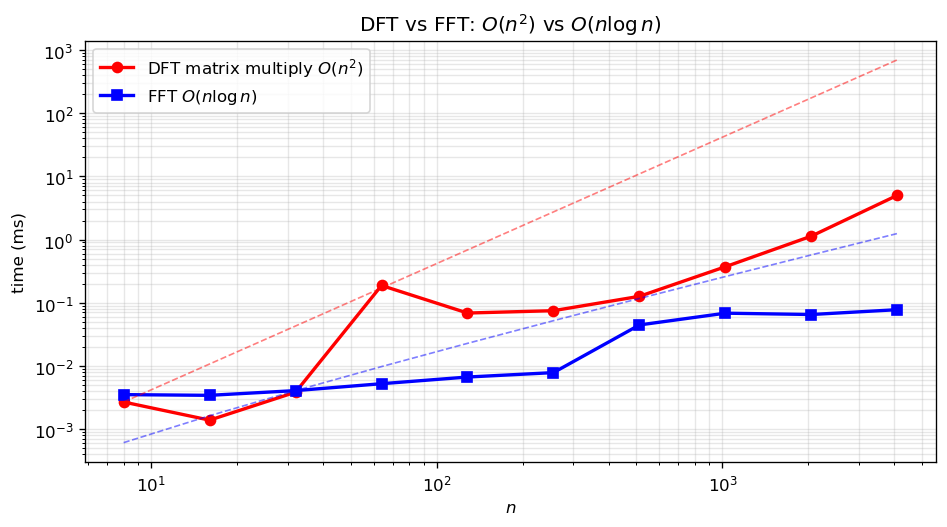

In [5]:
import time

n_values = [2**k for k in range(3, 13)]
times_dft = []
times_fft = []

for n_t in n_values:
    f_t = np.random.randn(n_t)
    F_t = np.exp(2j * np.pi / n_t * np.outer(np.arange(n_t), np.arange(n_t)))

    # DFT via matrix multiply
    reps = max(1, 100 // n_t)
    t0 = time.perf_counter()
    for _ in range(reps):
        _ = F_t @ f_t
    times_dft.append((time.perf_counter() - t0) / reps * 1e3)

    # FFT
    reps_fft = max(1, 1000 // n_t)
    t0 = time.perf_counter()
    for _ in range(reps_fft):
        _ = np.fft.fft(f_t)
    times_fft.append((time.perf_counter() - t0) / reps_fft * 1e3)

n_arr = np.array(n_values)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.loglog(n_arr, times_dft, 'r-o', ms=6, lw=2, label='DFT matrix multiply $O(n^2)$')
ax.loglog(n_arr, times_fft, 'b-s', ms=6, lw=2, label='FFT $O(n\\log n)$')
ax.loglog(n_arr, n_arr**2 * times_dft[0] / n_values[0]**2, 'r--', lw=1, alpha=0.5)
ax.loglog(n_arr, n_arr * np.log2(n_arr) * times_fft[2] / (n_values[2]*np.log2(n_values[2])),
          'b--', lw=1, alpha=0.5)
ax.set_xlabel('$n$'); ax.set_ylabel('time (ms)')
ax.set_title('DFT vs FFT: $O(n^2)$ vs $O(n\\log n)$')
ax.legend(fontsize=10); ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()

## Bibliographical resources

- Cooley, J. W. and Tukey, J. W. (1965). An algorithm for the machine calculation of complex Fourier series. *Mathematics of Computation*, 19(90), 297–301.
- van Loan, C. (1992). *Computational Frameworks for the Fast Fourier Transform*. SIAM.
- Briggs, W. L. and Henson, V. E. (1995). *The DFT: An Owner's Manual for the Discrete Fourier Transform*. SIAM.
- Frigo, M. and Johnson, S. G. (2005). The design and implementation of FFTW3. *Proceedings of the IEEE*, 93(2), 216–231.
- Trefethen, L. N. and Bau, D. (1997). *Numerical Linear Algebra*. SIAM.